### This is a short notebook comparing the two different $(z, \omega)$ methods used to generate SPDC in waveguides. Here we show that for the proper interaction strength, the *[Generator of Momentum](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.105.013708)* method (valid for arbitrary diserpsion) gives the same qualitative results as the first method which assumes linear dispersion. We consider both unpoled and aperiodically poled cases. This is to showcase that if one can safely work with linear dispersions, one should use the first method functions (much faster).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from custom_poling.core.target import Target
from custom_poling.core.custom_crystal import CustomCrystal
from NeedALight.spdc import SPulsed_lin, SPulsed_arb

This section introduces all relevant quantities needed to use the functions and generate the wanted properties.

In [2]:
#Parameters for calculations
N = 301  # Number of frequency values

###########################################
#Parameters for LINEAR dispersion functions
###########################################

Np = 0.0172 # Number of pump photons: Vary this to modify gain values
vp = 0.1  # pump velocity
l = 1.0  # amplification region length
sig = 1  # pump wave packet spread
a = 1.61 / 1.13  # from symmetric grp vel matching

#Ensuring that we are in the symmetric velocity group matching regime.
def symmetric_v(vp, sig, l, a):
    vi = vp / (1 - 2 * a * vp / (l * sig))
    vs = vp / (1 + 2 * a * vp / (l * sig))
    return vs, vi

vs, vi = symmetric_v(vp, sig, l, a)

#Frequency values
wi = -10
wf = 10
w = np.linspace(wi, wf, N)
dw = np.abs(w[1]-w[0])

#Defining gaussian pump pulse
def pump(x, Np, scale=1):
    return np.sqrt(Np)*np.exp(-((x) ** 2) / (2 * (sig*scale) ** 2)) / np.power(np.pi * (sig*scale)**2, 1 / 4)

#############################################
#Parameters for ARBITRATY dispersion function
#############################################

gamma = 1/(np.sqrt(2 * np.pi * np.abs( vs * vi * vp))) #Int. strength, include all variables needed
ks = w/vs  #signal dispersion
ki = w/vi #idler dispersion
kp_w = (w+w[:,np.newaxis])/vp  #pump dispersion matrix


####################
# Crystal properties
####################
Ndomain = 1000
dz = l / Ndomain
domain_width = dz
number_domains = Ndomain
L = number_domains * domain_width
k0 = np.pi / domain_width

# Numerical integration parameters for generating domain
k_range = 100/L

dk = k_range/401
k_array = np.arange(k0-k_range/2,k0+k_range/2,dk)

### Unpoled/periodic poling

We begin by considering an unpoled sample. Unlike the linear function, the arbitrary function requires us to specify the vector of spatial points and a corresponding poling domain. We use `Custom-Poling` to generate both.

In [3]:
# Create a custom crystal object
custom_crystal_gauss = CustomCrystal(domain_width, number_domains)
domain_middles_gauss = custom_crystal_gauss.domain_middles

# Spatial grid values for the non-linear region/crystal.
z_list = domain_middles_gauss - L / 2 - dz / 2

# Domain for a tophat potential
domain = np.asarray([1] * int(len(z_list)))  

Next we use the two different methods to generate the propagator, JSA, etc.

In [5]:
#Initializing pump
pump_Np=lambda x: pump(x, Np) #Scale is modified with poling, defined in the previous cell

#Linear
T_lin, J_lin, Ns_lin, K_lin, M_lin, Nums_lin, Numi_lin = SPulsed_lin(vs,vi,vp,pump_Np,[1],len(z_list)*dz,len(z_list)*dz,w)

#Arbitrary
T_arb, J_arb, Ns_arb, K_arb, M_arb, Nums_arb, Numi_arb = SPulsed_arb(ks, ki, kp_w, gamma, w, z_list, domain, pump_Np)

Comparing the JSAs

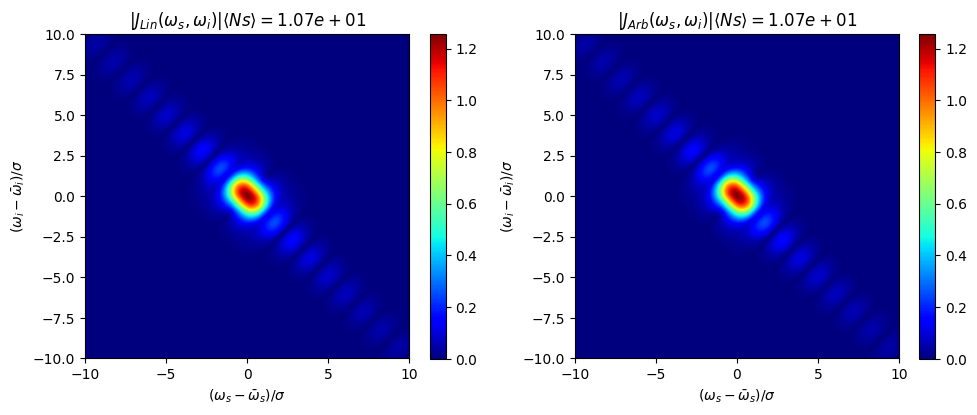

In [6]:
#Generating plot of JSA
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im = axs[0].imshow(np.abs(J_lin), cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
axs[0].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[0].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
axs[0].set_title(r"$|J_{Lin}(\omega_{s}, \omega_{i})|    \langle Ns \rangle = %1.2e $" %Ns_lin)
plt.colorbar(im, orientation="vertical")

im2 = axs[1].imshow(np.abs(J_arb), cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
axs[1].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[1].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
axs[1].set_title(r"$|J_{Arb}(\omega_{s}, \omega_{i})|    \langle Ns \rangle = %1.2e $" %Ns_arb)
plt.colorbar(im2, orientation="vertical")

fig.tight_layout()
plt.show()


Next we plot the Schmidt modes obtained from both methods. We plot the curves on the same figure to show that they are indistinguishable. Note that we multiply by a phase factor such that the imaginary part is 0 at the origin.

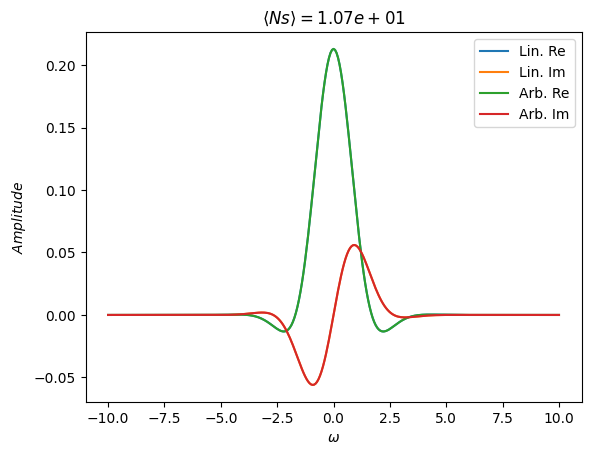

In [7]:
#Looking at the temporal modes via Nums matrix
mark=1 #this just takes the first eigenmode of interest. Choose a different value to look at different ones.
val_lin, u_lin = np.linalg.eigh(Nums_lin)
val_arb, u_arb = np.linalg.eigh(Nums_arb)
fig, ax1 = plt.subplots()

ax1.plot(w, np.real(np.exp(-1j*np.angle(u_lin[(N-1)//2,-mark]))*u_lin[:,-mark]), label='Lin. Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1.plot(w, np.imag(np.exp(-1j*np.angle(u_lin[(N-1)//2,-mark]))*u_lin[:,-mark]), label='Lin. Im')
ax1.plot(w, np.real(np.exp(-1j*np.angle(u_arb[(N-1)//2,-mark]))*u_arb[:,-mark]), label='Arb. Re') 
ax1.plot(w, np.imag(np.exp(-1j*np.angle(u_arb[(N-1)//2,-mark]))*u_arb[:,-mark]), label='Arb. Im')
ax1.set_xlabel(r"$\omega$")
ax1.set_ylabel(r"$Amplitude$")
ax1.set_title(r"$\langle Ns \rangle= %1.2e$" %Ns_lin)
ax1.legend()

plt.show()

Next we print out certain values to compare both methods.

In [8]:
print('Schmidt Numbers')
print('Lin. method: %f' %K_lin)
print("Arb. method: %f" %K_arb)

print('Signal Photon Numbers')
print('Lin. method: %f' %Ns_lin)
print('Arb. method: %f' %Ns_arb)

print('Max absolute JSA value')
print('Lin. method: %f' %np.amax(np.abs(J_lin)))
print('Arb. method: %f' %np.amax(np.abs(J_arb)))

print('Schmidt mode overlap: %f' %np.abs(np.vdot(u_lin[:,-mark],u_arb[:,-mark]))**2)

Schmidt Numbers
Lin. method: 1.062099
Arb. method: 1.062100
Signal Photon Numbers
Lin. method: 10.728846
Arb. method: 10.728839
Max absolute JSA value
Lin. method: 1.258013
Arb. method: 1.258012
Schmidt mode overlap: 1.000000


Qualitatively, we see that the JSA and the Schmidt modes from both methods are in good agreement. However, if we compare the numerical values there are some discrepancies. This is due to the fact the for the *Generator of Momentum* method, the equations of motion are $z$-dependent and as such the trotterization induces numerical errors. For better numerical agreement between both methods, increase the number of points for the spatial grid.

### Aperiodic Poling

We now consider aperiodic poling. We generate the crystal domain which produces a gaussian phase-matching function. We use the code and follow the examples of [Custom-Poling](https://github.com/abranczyk/custom-poling). We also redefine the pumps for both methods.

In [9]:
# Create a custom crystal object
custom_crystal_gauss = CustomCrystal(domain_width,number_domains)
domain_middles_gauss = custom_crystal_gauss.domain_middles

#Define and plot the target function
std = 10
height = 0.025
target_pmf_gauss = lambda k:1j*height*np.exp(-(k-k0)**2/(2*std**2))*np.exp(1j * L/2 * k)
target_gauss = Target(target_pmf_gauss,k_array)

# Compute and plot the target amplitude
target_amplitude_gauss = target_gauss.compute_amplitude(k0,domain_middles_gauss)

# Compute and plot the custom domains
custom_domains_gauss = custom_crystal_gauss.compute_domains(target_amplitude_gauss,k0)

#Shifting the domain such that we are at 0 central frequency
if len(custom_domains_gauss)==Ndomain:
    domain = custom_domains_gauss * np.asarray([1, -1] * int(Ndomain / 2)) 
else:
    domain = custom_domains_gauss * np.asarray([1, -1] * int(Ndomain / 2)+[1]) 


#Proper scale factor so that Gaussian PMF and Gaussian Pump have the same width
sc=std/(2*a)

#Scaled pump envelopes
Np_s = 2.2

#Initializing pump
pump_Np_s=lambda x: pump(x, Np_s*np.sqrt(sc), scale=sc)

Next we use the two different methods to generate the propagator, JSA, etc.

In [10]:
#Linear
T_lin_s, J_lin_s, Ns_lin_s, K_lin_s, M_lin_s, Nums_lin_s, Numi_lin_s = SPulsed_lin(vs,vi,vp,pump_Np_s,domain,dz,len(z_list)*dz,w)

#Arbitrary
T_arb_s, J_arb_s, Ns_arb_s, K_arb_s, M_arb_s, Nums_arb_s, Numi_arb_s = SPulsed_arb(ks, ki, kp_w, gamma, w, z_list, domain, pump_Np_s)

Comparing the JSAs.

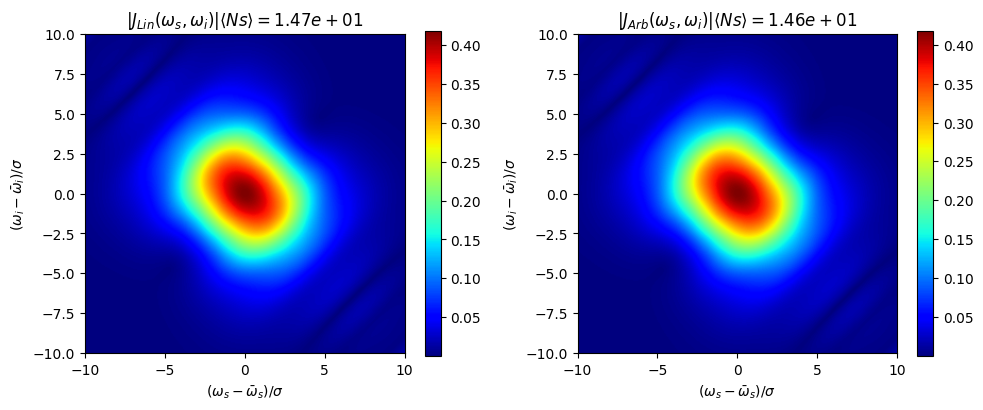

In [11]:
#Generating plot of JSA
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im = axs[0].imshow(np.abs(J_lin_s), cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
axs[0].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[0].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
axs[0].set_title(r"$|J_{Lin}(\omega_{s}, \omega_{i})|    \langle Ns \rangle = %1.2e $" %Ns_lin_s)
plt.colorbar(im, orientation="vertical")

im2 = axs[1].imshow(np.abs(J_arb_s), cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
axs[1].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[1].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
axs[1].set_title(r"$|J_{Arb}(\omega_{s}, \omega_{i})|    \langle Ns \rangle = %1.2e $" %Ns_arb_s)
plt.colorbar(im2, orientation="vertical")

fig.tight_layout()
plt.show()


Next we plot the Schmidt modes obtained from both methods. We plot the curves on the same figure to show that they are indistinguishable. Note that we multiply by a phase factor such that the imaginary part is 0 at the origin.

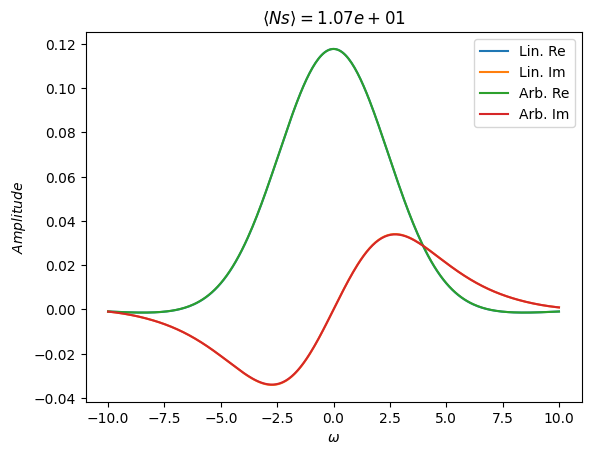

In [12]:
#Looking at the temporal modes via Nums matrix
mark=1 #this just takes the first eigenmode of interest. Choose a different value to look at different ones.
val_lin_s, u_lin_s = np.linalg.eigh(Nums_lin_s)
val_arb_s, u_arb_s = np.linalg.eigh(Nums_arb_s)
fig, ax1 = plt.subplots()

ax1.plot(w, np.real(np.exp(-1j*np.angle(u_lin_s[(N-1)//2,-mark]))*u_lin_s[:,-mark]), label='Lin. Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1.plot(w, np.imag(np.exp(-1j*np.angle(u_lin_s[(N-1)//2,-mark]))*u_lin_s[:,-mark]), label='Lin. Im')
ax1.plot(w, np.real(np.exp(-1j*np.angle(u_arb_s[(N-1)//2,-mark]))*u_arb_s[:,-mark]), label='Arb. Re') 
ax1.plot(w, np.imag(np.exp(-1j*np.angle(u_arb_s[(N-1)//2,-mark]))*u_arb_s[:,-mark]), label='Arb. Im')
ax1.set_xlabel(r"$\omega$")
ax1.set_ylabel(r"$Amplitude$")
ax1.set_title(r"$\langle Ns \rangle= %1.2e$" %Ns_lin)
ax1.legend()

plt.show()

Next we print out certain values to compare both methods.

In [13]:
print('Schmidt Numbers')
print('Lin. method: %f' %K_lin_s)
print("Arb. method: %f" %K_arb_s)

print('Signal Photon Numbers')
print('Lin. method: %f' %Ns_lin_s)
print('Arb. method: %f' %Ns_arb_s)

print('Max absolute JSA value')
print('Lin. method: %f' %np.amax(np.abs(J_lin_s)))
print('Arb. method: %f' %np.amax(np.abs(J_arb_s)))

print('Schmidt mode overlap: %f' %np.abs(np.vdot(u_lin_s[:,-mark],u_arb_s[:,-mark]))**2)

Schmidt Numbers
Lin. method: 1.020946
Arb. method: 1.020834
Signal Photon Numbers
Lin. method: 14.669698
Arb. method: 14.615659
Max absolute JSA value
Lin. method: 0.418048
Arb. method: 0.417552
Schmidt mode overlap: 0.999997


For aperiodic poling we again see good qualitative agreement between both methods. However, for the same spatial grid, the numerical discrepancies are bigger than in the unpoled case. 